Raw rows: 1215
After dedup rows: 1215
Full configs: 81  (expected 81 configs ideally)
Rows used in analysis: 1215  (full_cfg * expected_runs)
Saved cleaned dataset to: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/clean_full_runs.csv
Saved config summary: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/config_summary_sorted_by_auc.csv
Saved top10 table: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/table_top10_configs.csv

Top 10 by mean AUC:
optimizer activation  conv_layers  fc_layers  auc_mean  auc_ci_lo  auc_ci_hi  bal_mean  bal_ci_lo  bal_ci_hi  params_mean  time_mean
     adam       tanh            2          1  0.868302   0.838410   0.898194  0.717816   0.661352   0.774279     220097.0        0.0
     adam       tanh            3          1  0.855008   0.824224   0.885793  0.735082   0.688096   0.782068     193601.0        0.0
     adam       relu            2          1  0.845948   0.811403   0.880493  0.682994   0.61830

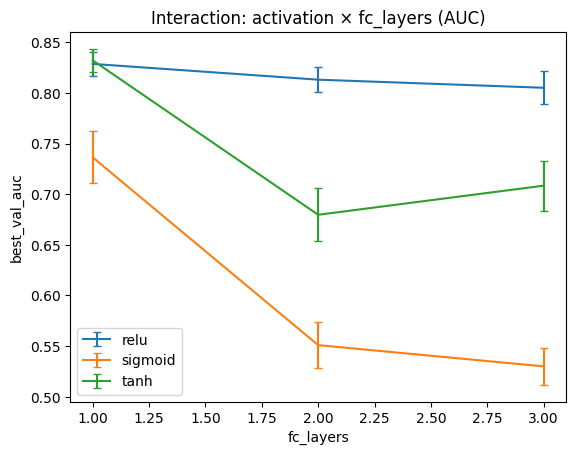

Saved figure: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/fig_interaction_activation_fc_auc.png


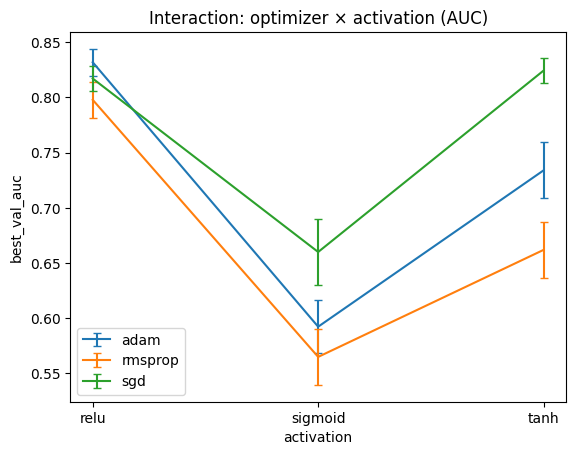

Saved figure: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/fig_interaction_optimizer_activation_auc.png


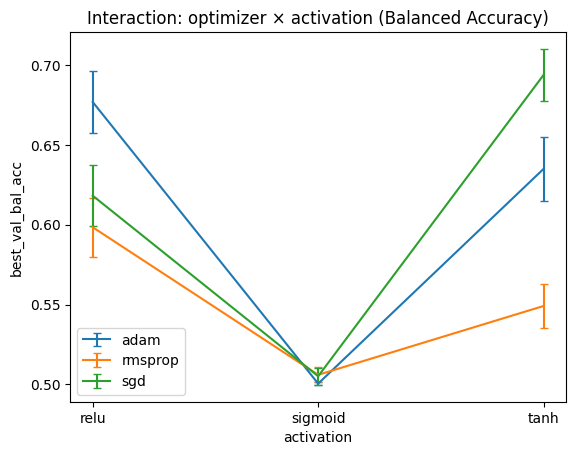

Saved figure: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/fig_interaction_optimizer_activation_balacc.png


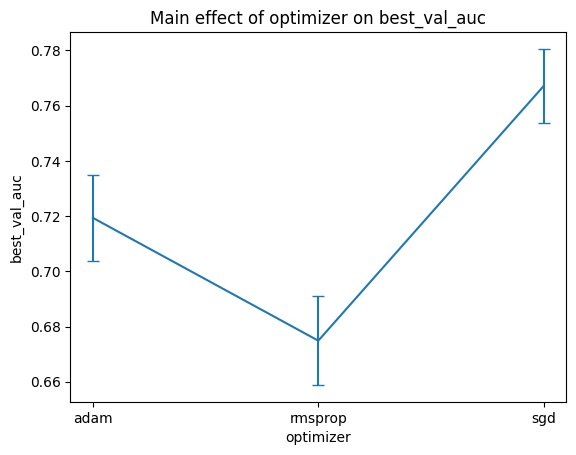

Saved figure: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/fig_main_best_val_auc_optimizer.png


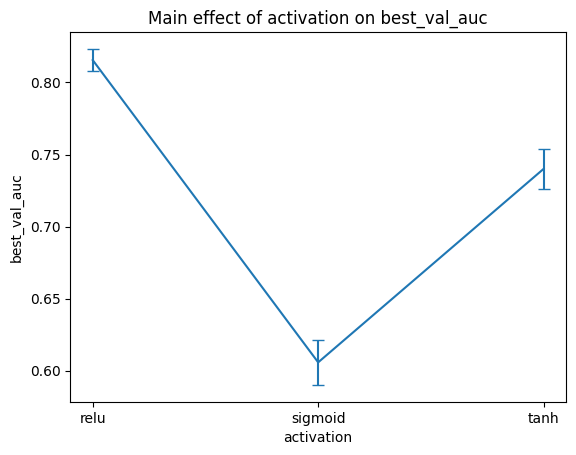

Saved figure: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/fig_main_best_val_auc_activation.png


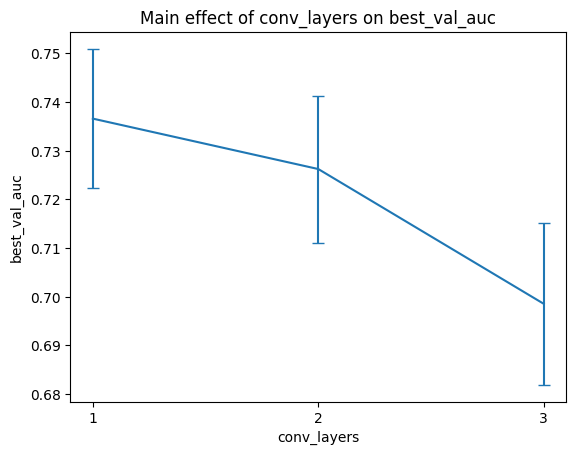

Saved figure: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/fig_main_best_val_auc_conv_layers.png


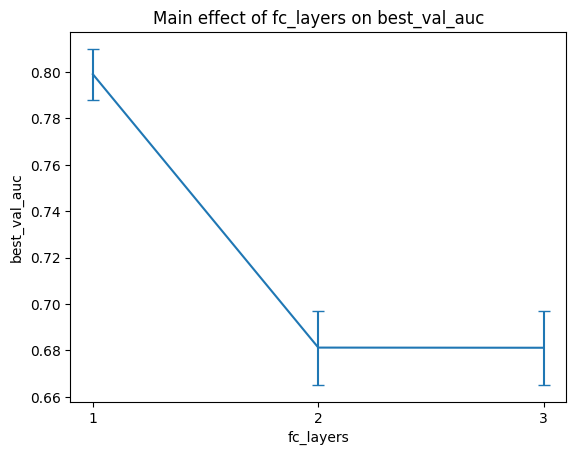

Saved figure: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/fig_main_best_val_auc_fc_layers.png


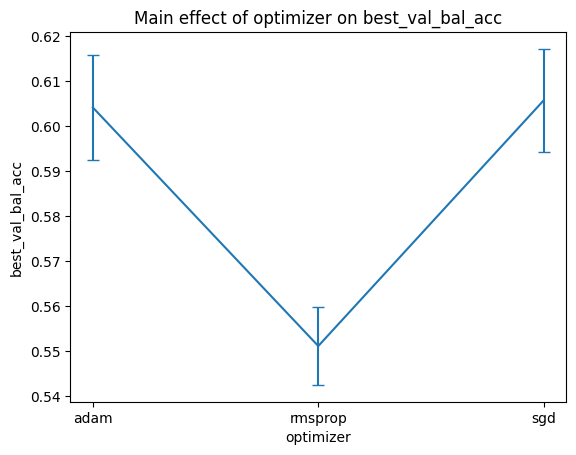

Saved figure: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/fig_main_best_val_bal_acc_optimizer.png


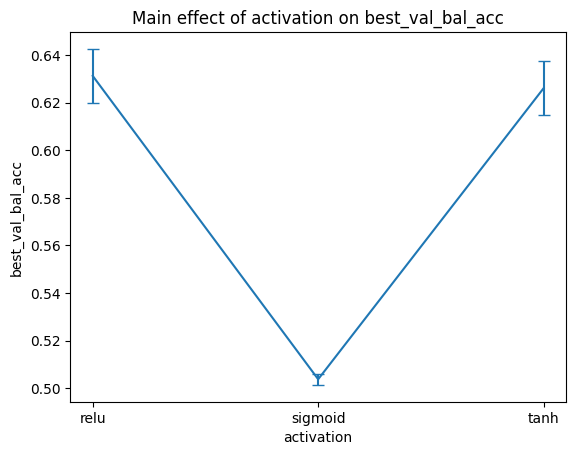

Saved figure: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/fig_main_best_val_bal_acc_activation.png


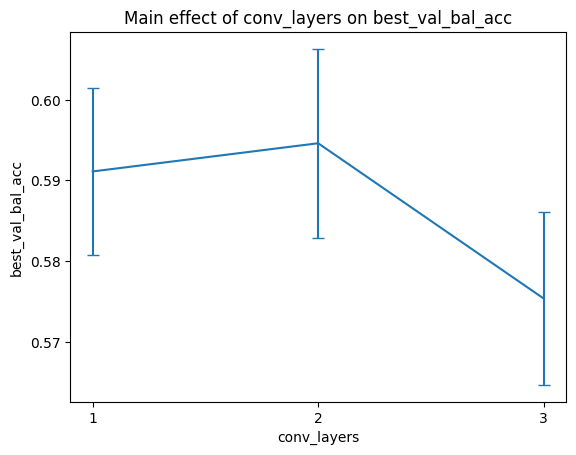

Saved figure: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/fig_main_best_val_bal_acc_conv_layers.png


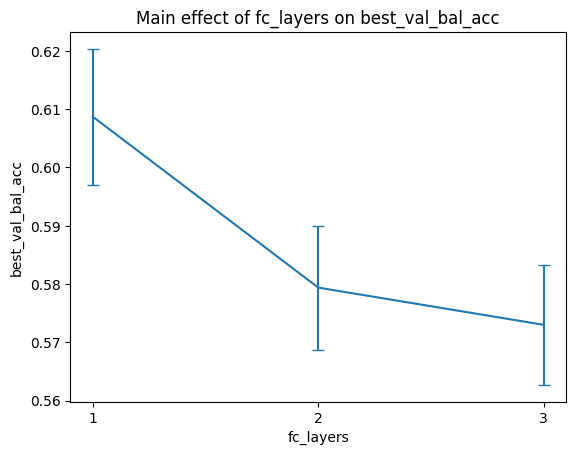

Saved figure: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/fig_main_best_val_bal_acc_fc_layers.png

Best config by mean AUC: ('adam', 'tanh', np.int64(2), np.int64(1)) mean_auc = 0.86830220713073
Saved best-vs-all table: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/best_vs_all_auc_holm.csv

How many configs are significantly WORSE than best (Holm-corrected)? 80 out of 80

Equivalent-top set (not significantly different & within 0.01 AUC):
Empty DataFrame
Columns: [optimizer, activation, conv_layers, fc_layers, mean_auc_cfg, bal_mean, params_mean, time_mean, p_value, p_holm]
Index: []
Saved: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/equivalent_top_set_auc.csv


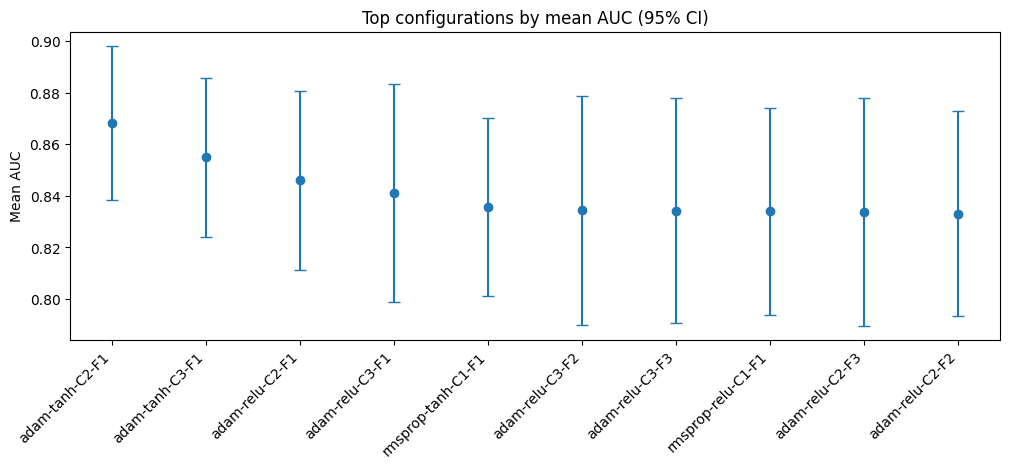

Saved: /content/drive/MyDrive/chapter5_planar_factorial/chapter5_outputs/fig_top10_auc_ci.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

os.makedirs(OUT_DIR, exist_ok=True)



df_raw = pd.read_csv(RESULTS_CSV)


for c in ["optimizer", "activation"]:
    df_raw[c] = df_raw[c].astype(str).str.lower().str.strip()
# -----------------------------

KEY = ["optimizer", "activation", "conv_layers", "fc_layers", "seed", "fold"]
CONFIG = ["optimizer", "activation", "conv_layers", "fc_layers"]

# -----------------------------
num_cols = [c for c in df_raw.columns if c not in KEY and pd.api.types.is_numeric_dtype(df_raw[c])]
df = df_raw.groupby(KEY, as_index=False)[num_cols].mean()

counts = df.groupby(CONFIG).size().reset_index(name="n_runs")
max_n = int(counts["n_runs"].max())
expected = max_n 

full_cfg = counts[counts["n_runs"] == expected][CONFIG]
df_full = df.merge(full_cfg, on=CONFIG, how="inner").copy()

print("Raw rows:", df_raw.shape[0])
print("After dedup rows:", df.shape[0])
print("Full configs:", full_cfg.shape[0], " (expected 81 configs ideally)")
print("Rows used in analysis:", df_full.shape[0], " (full_cfg * expected_runs)")

clean_csv = os.path.join(OUT_DIR, "clean_full_runs.csv")
df_full.to_csv(clean_csv, index=False)
print("Saved cleaned dataset to:", clean_csv)


# -----------------------------
def add_ci(summary_df, mean_col, std_col, n_col, out_lo, out_hi, alpha=0.05):
    tcrit = stats.t.ppf(1 - alpha/2, summary_df[n_col] - 1)
    se = summary_df[std_col] / np.sqrt(summary_df[n_col])
    summary_df[out_lo] = summary_df[mean_col] - tcrit * se
    summary_df[out_hi] = summary_df[mean_col] + tcrit * se
    return summary_df

agg = df_full.groupby(CONFIG).agg(
    n=("best_val_auc", "count"),

    auc_mean=("best_val_auc", "mean"),
    auc_std=("best_val_auc", "std"),

    bal_mean=("best_val_bal_acc", "mean"),
    bal_std=("best_val_bal_acc", "std"),

    acc_mean=("best_val_acc", "mean"),
    acc_std=("best_val_acc", "std"),

    f1_mean=("best_val_f1", "mean"),
    f1_std=("best_val_f1", "std"),

    loss_mean=("best_val_loss", "mean"),
    epoch_mean=("best_epoch", "mean"),

    time_mean=("train_seconds", "mean"),
    params_mean=("n_params", "mean"),
).reset_index()

agg = add_ci(agg, "auc_mean", "auc_std", "n", "auc_ci_lo", "auc_ci_hi")
agg = add_ci(agg, "bal_mean", "bal_std", "n", "bal_ci_lo", "bal_ci_hi")
agg = agg.sort_values("auc_mean", ascending=False)

agg_csv = os.path.join(OUT_DIR, "config_summary_sorted_by_auc.csv")
agg.to_csv(agg_csv, index=False)
print("Saved config summary:", agg_csv)

# Top table for thesis (Top 10)
top10 = agg.head(10).copy()
top10_csv = os.path.join(OUT_DIR, "table_top10_configs.csv")
top10.to_csv(top10_csv, index=False)
print("Saved top10 table:", top10_csv)

print("\nTop 10 by mean AUC:")
print(top10[CONFIG + ["auc_mean","auc_ci_lo","auc_ci_hi","bal_mean","bal_ci_lo","bal_ci_hi","params_mean","time_mean"]].to_string(index=False))


# -----------------------------
def main_effect_table(metric):
    out = {}
    for factor in ["optimizer", "activation", "conv_layers", "fc_layers"]:
        me = df_full.groupby(factor)[metric].agg(["mean","std","count"]).reset_index()
        me = me.sort_values("mean", ascending=False)
        out[factor] = me
        me.to_csv(os.path.join(OUT_DIR, f"main_effect_{metric}_{factor}.csv"), index=False)
    return out

main_effect_table("best_val_auc")
main_effect_table("best_val_bal_acc")


# -----------------------------
def partial_eta_sq(anova_tbl):
    tbl = anova_tbl.copy()
    ss_error = tbl.loc["Residual", "sum_sq"]
    pes = []
    for idx, row in tbl.iterrows():
        if idx == "Residual":
            pes.append(np.nan)
        else:
            ss = row["sum_sq"]
            pes.append(ss / (ss + ss_error))
    tbl["partial_eta_sq"] = pes
    return tbl

def run_anova(metric):
    formula = (
        f"{metric} ~ "
        "C(optimizer) + C(activation) + C(conv_layers) + C(fc_layers) + "
        "C(optimizer):C(activation) + C(optimizer):C(conv_layers) + C(optimizer):C(fc_layers) + "
        "C(activation):C(conv_layers) + C(activation):C(fc_layers) + C(conv_layers):C(fc_layers) + "
        "C(seed) + C(fold)"
    )
    model = smf.ols(formula, data=df_full).fit()
    a = sm.stats.anova_lm(model, typ=2)
    a = partial_eta_sq(a)
    a = a.sort_values("partial_eta_sq", ascending=False)
    return formula, model, a

for metric in ["best_val_auc", "best_val_bal_acc"]:
    formula, model, anova_tbl = run_anova(metric)
    out_csv = os.path.join(OUT_DIR, f"anova_{metric}.csv")
    anova_tbl.to_csv(out_csv)
    print("\n================================")
    print("ANOVA metric:", metric)
    print("Formula:", formula)
    print(anova_tbl[["sum_sq","df","F","PR(>F)","partial_eta_sq"]].head(12))
    print("Saved:", out_csv)


# -----------------------------
def interaction_plot(metric, x, hue, title, filename):
    # 计算 mean + 95% CI
    g = df_full.groupby([hue, x])[metric].agg(["mean","std","count"]).reset_index()
    tcrit = stats.t.ppf(0.975, g["count"] - 1)
    se = g["std"] / np.sqrt(g["count"])
    g["ci_lo"] = g["mean"] - tcrit * se
    g["ci_hi"] = g["mean"] + tcrit * se

    # 绘图
    plt.figure()
    for h in sorted(g[hue].unique()):
        sub = g[g[hue] == h].sort_values(x)
        plt.errorbar(sub[x], sub["mean"], yerr=(sub["mean"]-sub["ci_lo"], sub["ci_hi"]-sub["mean"]), label=str(h), capsize=3)
    plt.xlabel(x)
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    out_path = os.path.join(OUT_DIR, filename)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved figure:", out_path)

# AUC interaction plots
interaction_plot("best_val_auc", "fc_layers", "activation",
                 "Interaction: activation × fc_layers (AUC)", "fig_interaction_activation_fc_auc.png")
interaction_plot("best_val_auc", "activation", "optimizer",
                 "Interaction: optimizer × activation (AUC)", "fig_interaction_optimizer_activation_auc.png")

# Balanced accuracy interaction plot 
interaction_plot("best_val_bal_acc", "activation", "optimizer",
                 "Interaction: optimizer × activation (Balanced Accuracy)", "fig_interaction_optimizer_activation_balacc.png")


# -----------------------------
def main_effect_plot(metric, factor, title, filename):
    g = df_full.groupby(factor)[metric].agg(["mean","std","count"]).reset_index()
    tcrit = stats.t.ppf(0.975, g["count"] - 1)
    se = g["std"] / np.sqrt(g["count"])
    ci_lo = g["mean"] - tcrit * se
    ci_hi = g["mean"] + tcrit * se

    plt.figure()
    x = np.arange(len(g))
    plt.errorbar(x, g["mean"], yerr=(g["mean"]-ci_lo, ci_hi-g["mean"]), capsize=4)
    plt.xticks(x, g[factor].astype(str))
    plt.xlabel(factor)
    plt.ylabel(metric)
    plt.title(title)
    out_path = os.path.join(OUT_DIR, filename)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved figure:", out_path)

for metric in ["best_val_auc","best_val_bal_acc"]:
    for factor in ["optimizer","activation","conv_layers","fc_layers"]:
        main_effect_plot(metric, factor,
                         f"Main effect of {factor} on {metric}", f"fig_main_{metric}_{factor}.png")


# -----------------------------
def holm_correction(pvals, alpha=0.05):
    pvals = np.asarray(pvals)
    m = len(pvals)
    order = np.argsort(pvals)
    adjusted = np.empty(m, dtype=float)
    thresh = np.empty(m, dtype=float)
    for i, idx in enumerate(order):
        adjusted[idx] = (m - i) * pvals[idx]
        thresh[idx] = alpha / (m - i)
    adjusted = np.minimum.accumulate(adjusted[np.argsort(order)])[np.argsort(np.argsort(order))]
    return adjusted, thresh


best_row = agg.iloc[0]
best_cfg = tuple(best_row[c] for c in CONFIG)
print("\nBest config by mean AUC:", best_cfg, "mean_auc =", best_row["auc_mean"])

best_runs = df_full[
    (df_full["optimizer"]==best_cfg[0]) &
    (df_full["activation"]==best_cfg[1]) &
    (df_full["conv_layers"]==best_cfg[2]) &
    (df_full["fc_layers"]==best_cfg[3])
].set_index(["seed","fold"]).sort_index()

comparisons = []
pvals = []

for _, r in agg.iloc[1:].iterrows():
    cfg = tuple(r[c] for c in CONFIG)
    runs = df_full[
        (df_full["optimizer"]==cfg[0]) &
        (df_full["activation"]==cfg[1]) &
        (df_full["conv_layers"]==cfg[2]) &
        (df_full["fc_layers"]==cfg[3])
    ].set_index(["seed","fold"]).sort_index()


    joined = best_runs[["best_val_auc"]].join(runs[["best_val_auc"]], lsuffix="_best", rsuffix="_cfg", how="inner")
    diff = joined["best_val_auc_best"] - joined["best_val_auc_cfg"]
    t, p = stats.ttest_1samp(diff, 0.0)

    comparisons.append({
        "optimizer": cfg[0], "activation": cfg[1], "conv_layers": cfg[2], "fc_layers": cfg[3],
        "n_blocks": len(diff),
        "mean_auc_cfg": r["auc_mean"],
        "mean_diff_best_minus_cfg": diff.mean(),
        "p_value": p,
        "params_mean": r["params_mean"],
        "time_mean": r["time_mean"],
        "bal_mean": r["bal_mean"],
    })
    pvals.append(p)

adj, thresh = holm_correction(pvals, alpha=0.05)
for i, d in enumerate(comparisons):
    d["p_holm"] = adj[i]
    d["holm_sig"] = (adj[i] < 0.05)

cmp = pd.DataFrame(comparisons).sort_values("mean_diff_best_minus_cfg", ascending=False)
cmp_csv = os.path.join(OUT_DIR, "best_vs_all_auc_holm.csv")
cmp.to_csv(cmp_csv, index=False)
print("Saved best-vs-all table:", cmp_csv)

print("\nHow many configs are significantly WORSE than best (Holm-corrected)?",
      int(cmp["holm_sig"].sum()), "out of", cmp.shape[0])


equiv = cmp[(cmp["holm_sig"]==False) & (cmp["mean_diff_best_minus_cfg"]<=0.01)].sort_values("params_mean")
equiv_csv = os.path.join(OUT_DIR, "equivalent_top_set_auc.csv")
equiv.to_csv(equiv_csv, index=False)
print("\nEquivalent-top set (not significantly different & within 0.01 AUC):")
print(equiv[["optimizer","activation","conv_layers","fc_layers","mean_auc_cfg","bal_mean","params_mean","time_mean","p_value","p_holm"]].head(10).to_string(index=False))
print("Saved:", equiv_csv)


# -----------------------------
topN = 10
plot_df = agg.head(topN).copy()
labels = [f"{r.optimizer}-{r.activation}-C{int(r.conv_layers)}-F{int(r.fc_layers)}" for _, r in plot_df.iterrows()]

plt.figure(figsize=(12,4))
x = np.arange(topN)
y = plot_df["auc_mean"].values
yerr = np.vstack([y - plot_df["auc_ci_lo"].values, plot_df["auc_ci_hi"].values - y])
plt.errorbar(x, y, yerr=yerr, fmt="o", capsize=4)
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Mean AUC")
plt.title("Top configurations by mean AUC (95% CI)")
out_path = os.path.join(OUT_DIR, "fig_top10_auc_ci.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_path)
